# MIE 446 Aerospace Structures
## Lecture 02 — Finite Wings, Geometry and Load Paths

**Fall 2026 · 75 minutes · Student notebook**

**Driving question:** How do changes in wing geometry and load location change the demands on the wing root?

Lecture 01 introduced airfoil sections, forces and trustworthy calculations. This notebook develops the **finite-wing geometry and load-path unit in the syllabus**. A two-dimensional airfoil becomes a three-dimensional wing; surface loads become distributed beam loads; geometry choices become engineering trade-offs.

### What you will learn

1. Distinguish full span from semi-span and projected area from wetted area.
2. Derive and verify area, taper ratio, aspect ratio and mean aerodynamic chord for a trapezoidal wing.
3. Distinguish sweep, dihedral and angle of attack using the correct viewing directions.
4. Explain why a finite wing has spanwise-varying loading and induced drag.
5. Convert an assumed distributed load into a resultant, load centroid and root reaction moment.
6. Trace loads through skin, ribs, spars, stringers and root attachments.
7. Connect the course's printed semi-wing to its equivalent full-wing analytical geometry.

### Class route

| Minutes | Topic | Student evidence |
|---:|---|---|
| 0–5 | Setup and retrieval | One prediction |
| 5–20 | Planform geometry and derived quantities | Hand estimate and code comparison |
| 20–30 | Sweep and dihedral | Read top and front views |
| 30–40 | Finite-wing effects | Controlled aspect-ratio comparison |
| 40–55 | Distributed lift and load centroid | Predict the larger root moment |
| 55–65 | Structural load paths and cantilever model | Explain root reactions |
| 65–72 | Project geometry studio | Verify the course baseline |
| 72–75 | Exit ticket | Claim–Evidence–Check–Confidence–Limitation |

**How to use:** Save a copy in Drive. Run setup first; then work from top to bottom. Edit only the named inputs. Record predictions before running experiments. You need NumPy and Matplotlib, already present in standard Colab; no CAD installation is needed.

**Pacing:** Run one comparison per section during class. Additional parameter sweeps and the optional derivation at the end are for after class.

In [ ]:
#@title 0. Setup — run once { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from IPython.display import Markdown, display

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.18})
BLUE, ORANGE, GREEN, RED = "#245B8A", "#D96B20", "#267B52", "#A92333"

def integrate(values, coordinates):
    # Compatible with both NumPy 1.x and 2.x.
    f = getattr(np, "trapezoid", None)
    return f(values, coordinates) if f is not None else np.trapz(values, coordinates)

def positive(**values):
    for name, value in values.items():
        if not np.isfinite(value) or value <= 0:
            raise ValueError(f"{name} must be a finite positive number.")

def wing_metrics(semi_span, root_chord, tip_chord):
    positive(semi_span=semi_span, root_chord=root_chord, tip_chord=tip_chord)
    b = 2 * semi_span
    area = semi_span * (root_chord + tip_chord)
    taper = tip_chord / root_chord
    mac = (2/3) * root_chord * (1+taper+taper*taper)/(1+taper)
    return {"b": b, "S": area, "S_half": area/2, "lambda": taper,
            "AR": b*b/area, "MAC": mac, "mean_chord": area/b}

print("Ready: figures and experiments run without installing a CAD package.")

### Retrieval — make a prediction

Two symmetric wings have the **same full-wing area**. Wing B has a 20% larger span. Does its aspect ratio increase by 20%, increase by 44%, or remain unchanged?

Write your prediction below. Do not calculate yet. Later we will ask whether this geometry change also reduces the bending demand at the root.

In [ ]:
#@title 0A. Record your prediction { display-mode: "form" }
SPAN_PREDICTION = "Choose" #@param ["Choose", "Increase by 20%", "Increase by 44%", "Unchanged"]
SPAN_REASON = "" #@param {type:"string"}
if SPAN_PREDICTION == "Choose" or not SPAN_REASON.strip():
    print("Record a choice and one reason before continuing.")
else:
    print("Prediction:", SPAN_PREDICTION, "| Reason:", SPAN_REASON)

## 1. From an airfoil to a finite wing · 5–20 min

An airfoil describes a **section**. A wing has a finite span, a chord distribution, tips, and structural connections to the fuselage.

In this notebook, $y$ is spanwise, $x$ is aft from the root leading edge, and $z$ is upward. Let $s$ be **projected semi-span**, so full span $b=2s$. For a symmetric, linearly tapered wing, root chord is $c_r$, tip chord is $c_t$, and

$$
c(y)=c_r+(c_t-c_r)\frac{|y|}{s},\qquad -s\le y\le s.
$$

The taper ratio is $\lambda=c_t/c_r$. A rectangular wing has $\lambda=1$; ordinary taper has $0<\lambda<1$. This model does not include a fuselage cutout.

### Derive the area instead of memorizing it

A narrow spanwise strip has area $dS=c(y)\,dy$. Add the strips on both sides:

$$
S=2\int_0^s c(y)\,dy=s(c_r+c_t)=\frac{b}{2}(c_r+c_t).
$$

$S$ is the **full-wing projected planform area**, not the sum of upper and lower skin areas. Its units are length squared.

$$
AR=\frac{b^2}{S},\qquad c_{\mathrm{mean}}=\frac{S}{b}=\frac{c_r+c_t}{2}.
$$

For a rectangular wing only, $AR=b/c$. In the general case, use $b^2/S$.

### Mean aerodynamic chord is a different average

The geometric mean aerodynamic chord weights longer chords more strongly:

$$
\bar c=\frac{2}{S}\int_0^s c(y)^2\,dy
=\frac{2c_r}{3}\frac{1+\lambda+\lambda^2}{1+\lambda}.
$$

It is not generally equal to $S/b$. This geometrical definition does not establish a real wing's center of pressure or aerodynamic center. For a rectangle, both chord averages reduce to $c_r$.

**Read the next figure:** identify both tips, the centerline, $s$, $b$, $c_r$ and $c_t$.

In [ ]:
#@title 1A. Figure and experiment — trapezoidal wing geometry { display-mode: "form" }
SEMI_SPAN_M = 4.0 #@param {type:"number"}
ROOT_CHORD_M = 1.8 #@param {type:"number"}
TIP_CHORD_M = 0.9 #@param {type:"number"}
metrics = wing_metrics(SEMI_SPAN_M, ROOT_CHORD_M, TIP_CHORD_M)
s, cr, ct = SEMI_SPAN_M, ROOT_CHORD_M, TIP_CHORD_M
y = np.linspace(-s, s, 401)
c = cr + (ct-cr)*np.abs(y)/s
fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
ax.fill_between(y, 0, c, color=BLUE, alpha=0.16)
ax.plot(y, c, color=BLUE, lw=2, label="Trailing edge")
ax.plot(y, np.zeros_like(y), color=GREEN, lw=2, label="Leading edge")
ax.axvline(0, color="gray", ls="--")
for yp, chord, label in [(0,cr,"root chord"),(s,ct,"tip chord")]:
    ax.annotate("", (yp,chord), (yp,0), arrowprops={"arrowstyle":"<->","color":RED,"lw":2})
    ax.text(yp-0.05*s, chord/2, label, ha="right", color=RED,
            bbox={"facecolor":"white","edgecolor":"none","alpha":0.85})
ax.annotate("", (s,-0.28*cr), (-s,-0.28*cr), arrowprops={"arrowstyle":"<->"})
ax.text(0,-0.33*cr, f"Full span b = {2*s:g} m", ha="center", va="top")
ax.annotate("", (s,-0.12*cr), (0,-0.12*cr), arrowprops={"arrowstyle":"<->"})
ax.text(s/2,-0.14*cr, f"Semi-span s = {s:g} m", ha="center", va="top", fontsize=9)
ax.set(xlabel="Spanwise y (m)", ylabel="Aft x (m)",
       title="Top view — projected planform, both halves included")
ax.set_xlim(-1.12*s,1.12*s)
ax.set_ylim(-0.48*cr,1.25*max(cr,ct))
ax.legend(loc="upper left", fontsize=9)
ax.set_aspect("equal", adjustable="box")
plt.show()
for key in ["S","S_half","lambda","AR","MAC","mean_chord"]:
    unit = "m²" if key in ["S","S_half"] else "m" if key in ["MAC","mean_chord"] else ""
    print(f"{key:12s} = {metrics[key]:.5f} {unit}")
area_numerical = integrate(c,y)
assert np.isclose(area_numerical, metrics["S"], rtol=1e-8)
print("Independent strip-integration check: PASS")

### Test the formula with one controlled change

Keep the area fixed and multiply the span by $k$. Scale **both** chords by $1/k$ to preserve area and taper:

$$
\frac{AR_2}{AR_1}=k^2.
$$

If instead the chords were held fixed, $S$ would grow with span and $AR$ would grow only by $k$. Always name the fixed quantities.

**Do first:** revise your prediction if needed, then run the comparison.

In [ ]:
#@title 1B. Experiment — longer span at fixed area { display-mode: "form" }
SPAN_FACTOR = 1.20 #@param {type:"number"}
positive(span_factor=SPAN_FACTOR)
B = wing_metrics(s*SPAN_FACTOR, cr/SPAN_FACTOR, ct/SPAN_FACTOR)
fig, axes = plt.subplots(1,2,figsize=(10,3.8),layout="constrained")
for ax, label, m, ss, rr, tt in [
    (axes[0],"A: baseline",metrics,s,cr,ct),
    (axes[1],"B: same area",B,s*SPAN_FACTOR,cr/SPAN_FACTOR,ct/SPAN_FACTOR)]:
    yy=np.linspace(-ss,ss,201)
    ax.fill_between(yy,0,rr+(tt-rr)*np.abs(yy)/ss,color=BLUE,alpha=0.25)
    ax.set(xlim=(-1.1*max(s,s*SPAN_FACTOR),1.1*max(s,s*SPAN_FACTOR)),
           ylim=(-0.1,1.3*max(cr,ct,cr/SPAN_FACTOR,ct/SPAN_FACTOR)),
           xlabel="y (m)",ylabel="x (m)",title=f"{label}\nS={m['S']:.2f} m², AR={m['AR']:.2f}")
    ax.set_aspect("equal", adjustable="box")
plt.show()
assert np.isclose(B["S"],metrics["S"])
print(f"Area ratio = {B['S']/metrics['S']:.3f}")
print(f"Aspect-ratio ratio = {B['AR']/metrics['AR']:.3f}; change = {(SPAN_FACTOR**2-1)*100:.1f}%")
print("At k=1.20, the correct opening prediction is +44%.")

## 2. Sweep and dihedral require different views · 20–30 min

**Sweep** is a planform angle. Always specify the reference line: leading-edge sweep $\Lambda_{LE}$ and quarter-chord sweep $\Lambda_{c/4}$ are generally different on a tapered wing.

$$
x_{LE}(y)=|y|\tan\Lambda_{LE},\qquad
x_{c/4}(y)=x_{LE}(y)+\frac{c(y)}4.
$$

On the right half of a trapezoid,

$$
\tan\Lambda_{c/4}=\tan\Lambda_{LE}+\frac{c_t-c_r}{4s}.
$$

**Dihedral** $\Gamma$ is visible from the front. In our projected-span convention,

$$
z(y)=|y|\tan\Gamma,\qquad \ell_{\mathrm{half}}=\frac{s}{\cos\Gamma}.
$$

Here $\ell_{\mathrm{half}}$ is the length along the tilted span line, whereas $s$ is horizontal semi-span. Positive dihedral raises the tips; negative dihedral lowers them. Dihedral contributes to roll response to sideslip, but this geometry plot is not a stability calculation.

Angle of attack is a third concept: the chord's orientation relative to airflow. Rotating a planform on this page does not compute angle of attack.

**Predict:** with projected span and chords held fixed, does adding leading-edge sweep change $S$ or $AR$? Does it change the aft location of the tip?

Source for viewing conventions and geometry definitions: [NASA Wing Geometry](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/wing-geometry/).

In [ ]:
#@title 2A. Experiment — separate top and front views { display-mode: "form" }
LE_SWEEP_DEG = 20.0 #@param {type:"number"}
DIHEDRAL_DEG = 6.0 #@param {type:"number"}
SWEEP_PREDICTION = "Choose" #@param ["Choose", "Area changes", "Area stays fixed"]
if not (-60 <= LE_SWEEP_DEG <= 60 and -25 <= DIHEDRAL_DEG <= 25):
    raise ValueError("For this classroom model, use sweep within ±60° and dihedral within ±25°.")
le=np.abs(y)*np.tan(np.deg2rad(LE_SWEEP_DEG))
quarter=le+c/4
z=np.abs(y)*np.tan(np.deg2rad(DIHEDRAL_DEG))
q_sweep=np.rad2deg(np.arctan(np.tan(np.deg2rad(LE_SWEEP_DEG))+(ct-cr)/(4*s)))
fig, axes=plt.subplots(1,2,figsize=(11,4.3),layout="constrained")
axes[0].fill_between(y,le,le+c,color=BLUE,alpha=0.18)
axes[0].plot(y,le,color=GREEN,label="Leading edge")
axes[0].plot(y,quarter,"--",color=RED,label="Quarter chord")
axes[0].plot(y,le+c,color=BLUE,label="Trailing edge")
axes[0].set(title=f"TOP: LE sweep {LE_SWEEP_DEG:g}°; quarter chord {q_sweep:.1f}°",
            xlabel="Spanwise y (m)",ylabel="Aft x (m)")
axes[0].legend(fontsize=9,loc="upper center",bbox_to_anchor=(0.5,-0.35),ncol=3)
axes[1].plot(y,z,color=BLUE,lw=3)
axes[1].axhline(0,color="gray",ls="--")
axes[1].set(title=f"FRONT: dihedral {DIHEDRAL_DEG:g}°",xlabel="Spanwise y (m)",ylabel="Height z (m)")
axes[1].set_ylim(-0.55*s,0.55*s)
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
plt.show()
print(f"Projected S = {integrate((le+c)-le,y):.4f} m²; AR = {metrics['AR']:.4f}")
print(f"Length along tilted half-span = {s/np.cos(np.deg2rad(DIHEDRAL_DEG)):.4f} m")
print("Sweep changes chordwise location, not projected area in this fixed-span/fixed-chord construction.")

## 3. A finite wing is not an infinite airfoil · 30–40 min

A lifting finite wing produces a trailing vortex system and downwash. The local flow direction differs from the undisturbed freestream; this creates an induced-drag contribution. Loading also varies across the span.

A useful classical comparison is

$$
C_{D_i}=\frac{C_L^2}{\pi e AR}.
$$

$C_L$ refers to the entire wing; $e$ is a span-efficiency factor. The simple planar lifting-line idealization has $e=1$ for elliptical loading. We specify $e$ as an assumed input: this notebook does **not** infer it from taper or NACA digits.

With fixed density, speed, total lift and area, $q$, $C_L$ and the conversion $D_i=qSC_{D_i}$ are fixed except for the aspect-ratio effect. Increasing span by $k$ at fixed area and $e$ reduces this model's induced drag by $1/k^2$.

This concerns **induced drag only**. It does not establish total drag, structural mass, stall behavior, efficiency of a printed wing or the best overall design.

**Predict first:** for $k=1.20$, will induced drag be about 17%, 31%, or 44% lower? The next section asks what happens to root bending for the same total load.

Reference: [NASA Induced Drag Coefficient](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/induced-drag-coefficient/).

In [ ]:
#@title 3A. Experiment — aspect ratio and induced drag { display-mode: "form" }
WING_CL = 0.7 #@param {type:"number"}
SPAN_EFFICIENCY = 0.85 #@param {type:"number"}
DRAG_PREDICTION_PERCENT_REDUCTION = 31.0 #@param {type:"number"}
if not 0 < SPAN_EFFICIENCY <= 1:
    raise ValueError("Use 0 < e <= 1 for this idealized planar-wing comparison.")
ar=np.linspace(3,18,200)
cdi=WING_CL**2/(np.pi*SPAN_EFFICIENCY*ar)
baseline_cdi=WING_CL**2/(np.pi*SPAN_EFFICIENCY*metrics["AR"])
changed_cdi=WING_CL**2/(np.pi*SPAN_EFFICIENCY*B["AR"])
fig, ax=plt.subplots(figsize=(9,4.3),layout="constrained")
ax.plot(ar,cdi,color=BLUE,lw=2)
ax.scatter([metrics["AR"]],[baseline_cdi],color=RED,s=65,label="A: baseline")
ax.scatter([B["AR"]],[changed_cdi],color=GREEN,s=65,label="B: changed span, fixed area")
ax.legend(fontsize=9)
ax.set(xlabel="Aspect ratio AR",ylabel=r"Induced-drag coefficient $C_{D_i}$",
       title="Fixed CL and span efficiency — a limited comparison")
plt.show()
reduction=100*(1-1/SPAN_FACTOR**2)
print(f"Baseline CDi = {baseline_cdi:.5f}; modified CDi = {changed_cdi:.5f}")
print(f"Predicted reduction = {DRAG_PREDICTION_PERCENT_REDUCTION:.1f}%; computed reduction = {reduction:.2f}%")
print("Lower induced drag is one objective. It does not settle the structural trade-off.")

## 4. From a surface load to a spanwise load · 40–55 min

Pressure and shear act on surface area. After integrating their vertical components around a section, we represent the resulting upward force per unit span by $w(y)$, measured in **N/m**.

For a simple small-slope pressure sketch one might write $w(y)\approx\int[p_{\mathrm{lower}}-p_{\mathrm{upper}}]\,dx$. The more general definition integrates the relevant components of surface traction. Neither pressure nor $w(y)$ is calculated from the NACA shape alone here.

A narrow strip of width $dy$ carries force

$$
dF=w(y)\,dy.
$$

For one half-wing with $0\le y\le s$,

$$
F_h=\int_0^s w(y)\,dy,\qquad
\bar y=\frac{\int_0^s y\,w(y)\,dy}{F_h}.
$$

$F_h$ is in N; $\bar y$ is in m. The applied moment magnitude about the root is

$$
M_{\mathrm{load}}=\int_0^s y\,w(y)\,dy=F_h\bar y.
$$

**This is the central structural observation:** equal total forces can produce different root moments because the load centroids differ.

### Three assumed load distributions

These are teaching load cases, not predictions for our printed wing. Normalize each to the **same half-wing force** $F_h$.

| Distribution | $w(y)$ | Centroid $\bar y$ |
|---|---|---|
| Uniform | $F_h/s$ | $s/2$ |
| Root-heavy triangular | $(2F_h/s)(1-y/s)$ | $s/3$ |
| Elliptical | $(4F_h/\pi s)\sqrt{1-(y/s)^2}$ | $4s/(3\pi)$ |

The uniform case has a nonzero idealized tip load and is used as a simple beam benchmark. Real finite-wing aerodynamics needs a separate model or measurements. A tapered planform does not automatically produce an elliptical loading.

### Short worked derivation

For uniform loading $w=F_h/s$:

$$
M_{\mathrm{load}}=\frac{F_h}{s}\int_0^s y\,dy=\frac{F_hs}{2}.
$$

For a root-heavy triangle the same integration gives $F_hs/3$. With the same total force and semi-span, the uniform load therefore produces a root moment **50% larger**.

In [ ]:
#@title 4A. Predict — same force, different location { display-mode: "form" }
LARGEST_MOMENT = "Choose" #@param ["Choose", "Uniform", "Root-heavy triangular", "Elliptical", "All equal"]
LOAD_REASON = "" #@param {type:"string"}
print("Record your ranking before running 4B.")
if LARGEST_MOMENT != "Choose" and LOAD_REASON.strip():
    print("Prediction:",LARGEST_MOMENT,"|",LOAD_REASON)

In [ ]:
#@title 4B. Experiment — compare equal-force distributions { display-mode: "form" }
HALF_WING_FORCE_N = 1200.0 #@param {type:"number"}
LOAD_SEMI_SPAN_M = 4.0 #@param {type:"number"}
positive(force=HALF_WING_FORCE_N, span=LOAD_SEMI_SPAN_M)
ss=LOAD_SEMI_SPAN_M
ys=np.linspace(0,ss,4001)
load_shapes={
    "Uniform": np.ones_like(ys),
    "Root-heavy triangular": 1-ys/ss,
    "Elliptical": np.sqrt(np.maximum(0,1-(ys/ss)**2))
}
loads={name: shape*HALF_WING_FORCE_N/integrate(shape,ys)
       for name,shape in load_shapes.items()}
centroids={}
fig, axes=plt.subplots(1,2,figsize=(11,4.7),layout="constrained")
for (name,w),color in zip(loads.items(),[BLUE,ORANGE,GREEN]):
    centroid=integrate(ys*w,ys)/integrate(w,ys)
    centroids[name]=centroid
    axes[0].plot(ys,w,color=color,label=name,lw=2)
    axes[1].bar(name.replace(" ","\n"),HALF_WING_FORCE_N*centroid,color=color)
    print(f"{name}: force={integrate(w,ys):.2f} N; centroid={centroid:.4f} m; moment={HALF_WING_FORCE_N*centroid:.2f} N m")
axes[0].set(xlabel="y from root (m)",ylabel="w(y) (N/m)",title="Equal area under all three curves")
axes[0].legend(fontsize=9)
axes[1].set(ylabel="Applied root moment magnitude (N m)",title="Equal force does not mean equal moment")
plt.show()
expected={"Uniform":ss/2,"Root-heavy triangular":ss/3,"Elliptical":4*ss/(3*np.pi)}
for name,value in centroids.items():
    assert np.isclose(value,expected[name],rtol=1e-4)
print("Numerical centroids agree with independent closed-form expressions: PASS")
print("Ranking: Uniform > Elliptical > Root-heavy triangular.")

### Return to the span trade-off

If the load's normalized shape $w(y/s)$ and total half-wing force are fixed, its centroid is a fixed fraction of $s$. Thus

$$
\frac{M_{\mathrm{root},2}}{M_{\mathrm{root},1}}=k.
$$

For a 20% larger span: our earlier model predicted about **31% less induced drag**, but the half-wing root moment is **20% larger**. The longer span also changes stiffness and weight, which we have not yet calculated.

If instead load **intensity in N/m** were held fixed for a uniform load, force would grow with $s$ and moment would grow with $s^2$. The fixed quantities determine the answer.

## 5. How the structure carries the load · 55–65 min

The wing is an interconnected structure. Skin panels carry local pressure to supporting members, ribs preserve section shape and distribute local loads, spars and their caps/webs carry major bending and shear, and stringers stiffen skin and share spanwise load. Closed skin-and-spar cells also resist torsion. Load sharing depends on stiffness and connections; there is no single universal serial path through every component.

Inspect the labeled FAA cutaway below. Point to a rib and a spar and explain why they run in different directions. Identify the skin and stringers, then trace a plausible path to the root attachment.

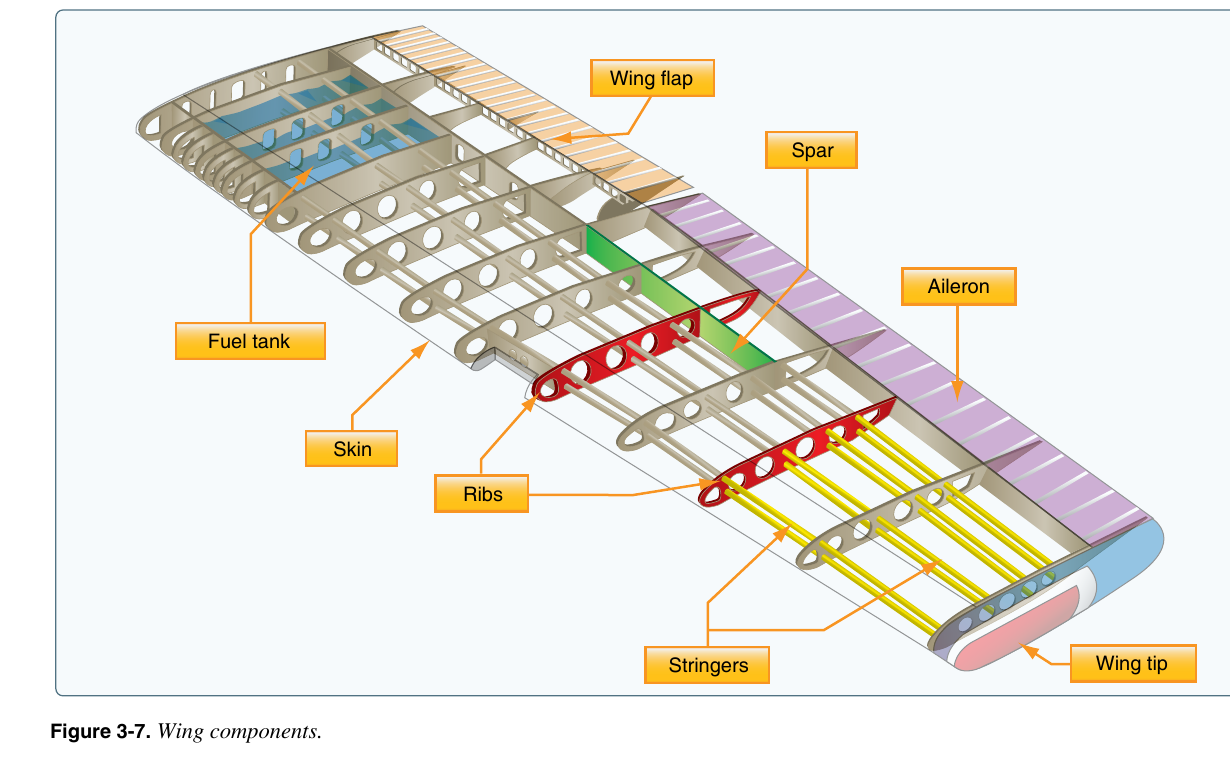

Source: FAA, *Pilot's Handbook of Aeronautical Knowledge*, Chapter 3, Figure 3-7, p. 3-5. [Original figure and chapter](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf).

The illustration shows a conventional wing. Our printed model approximates selected geometric features; its carbon rods and printed interfaces require their own physical inspection.

### Replace the half-wing with a cantilever

For this first structural idealization, clamp the root and leave the tip free. Replace the upward aerodynamic load by $w(y)$ acting on a beam. Ignore self-weight, fuel, engines, torsion and flexibility of the attachment **for this example**.

Take upward force and counterclockwise external moment as positive in the next **side-view** diagram. Upward loading on the right of the root produces a positive applied moment. Equilibrium requires

$$
R_z+F_h=0,\qquad M_R+F_h\bar y=0.
$$

Therefore the root force is **downward**, $R_z=-F_h$, and the reaction moment is **clockwise**, $M_R=-F_h\bar y$. Moment magnitudes from Section 4 are positive; the signed reaction here is negative. These statements use different conventions for different purposes, not contradictory physics.

A reaction moment is not a point force. When replacing a distributed load with a single force, place that force at its centroid; moving it to the root without adding a couple loses the moment.

In [ ]:
#@title 5A. Figure and check — loaded half-wing and equivalent resultant { display-mode: "form" }
LOAD_CASE = "Elliptical" #@param ["Uniform", "Root-heavy triangular", "Elliptical"]
w=loads[LOAD_CASE]
F=integrate(w,ys)
ybar=centroids[LOAD_CASE]
MR=-F*ybar
fig, axes=plt.subplots(2,1,figsize=(10,6.5),layout="constrained")
for ax in axes:
    ax.add_patch(Rectangle((-0.055*ss,-0.12),0.055*ss,0.24,facecolor="0.65",hatch="///"))
    ax.plot([0,ss],[0,0],color="black",lw=4)
    ax.annotate("",(0,-0.7),(0,0),arrowprops={"arrowstyle":"-|>","color":RED,"lw":2})
    ax.text(0.07*ss,-0.62,f"Root reaction Rz = {-F:.0f} N",color=RED)
    ax.set(xlim=(-0.12*ss,1.12*ss),ylim=(-1.1,1.1),xlabel="Distance from root y (m)")
    ax.set_yticks([])
    ax.grid(axis="x")
for yi, wi in zip(ys[::400],w[::400]):
    axes[0].annotate("",(yi,0.8*wi/max(w)),(yi,0),
                     arrowprops={"arrowstyle":"-|>","color":BLUE,"lw":1.6})
axes[0].set_title(f"Distributed upward load: {LOAD_CASE} (arrow scale schematic)")
axes[1].annotate("",(ybar,0.88),(ybar,0),arrowprops={"arrowstyle":"-|>","color":BLUE,"lw":3})
axes[1].text(ybar+0.07*ss,0.65,f"Fh = {F:.0f} N\ncentroid = {ybar:.3f} m",color=BLUE)
axes[1].axvline(ybar,color=BLUE,ls=":",alpha=0.5)
axes[1].set_title("Equivalent force at the load centroid")
for ax in axes:
    ax.text(0.53*ss,-0.95,f"Clockwise root couple MR = {MR:.1f} N m",color=ORANGE,ha="center")
plt.show()
Rz=-F
assert abs(Rz+F)<1e-8
assert abs(MR+integrate(ys*w,ys))<1e-8
print("Vertical-force and root-moment equilibrium: PASS")

### What has and has not been established

The two root reactions balance the **assumed** applied load. They do not establish stress, deflection, buckling, joint strength or flight safety. Those questions need further mechanics, material data and boundary-condition evidence.

An actual wing has downward inertial/weight contributions and possibly other concentrated loads. Their signed forces and moments must be included. This upward-load-only example illustrates load transfer, not a certified load case.

**Pair discussion, 60 seconds:** one student points to the beam support and explains what it assumes. The other names a real feature or load omitted by that support model. Swap roles.

## 6. Connect the theory to the course project · 65–72 min

Our physical project is **one semi-wing**, nominally 450 mm long with 160 mm root chord and 100 mm tip chord. Full-wing metrics assume a mirrored partner:

$$
s=0.450\ \mathrm{m},\quad b=0.900\ \mathrm{m},\quad
S_h=\frac{s(c_r+c_t)}{2}=0.0585\ \mathrm{m^2},
$$

$$
S=2S_h=0.1170\ \mathrm{m^2},\qquad
AR=\frac{0.900^2}{0.1170}=6.9231.
$$

Using $s^2/S_h$ gives **half** the correct full-wing aspect ratio. It mixes the semi-wing geometry with a full-wing definition.

### Before running the studio

Predict the effect of increasing only the tip chord from 100 to 120 mm with fixed semi-span and root chord. Area should rise, taper should rise, and aspect ratio should fall. Write why before checking.

The studio below is a geometry exercise. It does not create printable files or apply all project release gates. The separate Code-to-Print notebook performs CAD construction and export after the physical coupon record is complete.

In [ ]:
#@title 6A. Project studio — verify units and semi-wing conventions { display-mode: "form" }
PROJECT_SEMI_SPAN_MM = 450.0 #@param {type:"number"}
PROJECT_ROOT_CHORD_MM = 160.0 #@param {type:"number"}
PROJECT_TIP_CHORD_MM = 100.0 #@param {type:"number"}
COMPARE_TIP_CHORD_MM = 120.0 #@param {type:"number"}
PROJECT_PREDICTION_REASON = "" #@param {type:"string"}
if not 0 < PROJECT_TIP_CHORD_MM <= PROJECT_ROOT_CHORD_MM:
    raise ValueError("Use 0 < tip chord <= root chord.")
if not 0 < COMPARE_TIP_CHORD_MM <= PROJECT_ROOT_CHORD_MM:
    raise ValueError("Comparison tip chord must be positive and no larger than root chord.")
pm=wing_metrics(PROJECT_SEMI_SPAN_MM,PROJECT_ROOT_CHORD_MM,PROJECT_TIP_CHORD_MM)
pc=wing_metrics(PROJECT_SEMI_SPAN_MM,PROJECT_ROOT_CHORD_MM,COMPARE_TIP_CHORD_MM)
print("All inputs are millimetres; all area outputs below are square millimetres.")
for k in ["b","S_half","S","lambda","AR","MAC"]:
    print(f"{k:10s} baseline={pm[k]:.4f}   comparison={pc[k]:.4f}")
si=wing_metrics(PROJECT_SEMI_SPAN_MM/1000,PROJECT_ROOT_CHORD_MM/1000,PROJECT_TIP_CHORD_MM/1000)
assert np.isclose(pm["S"]/1e6,si["S"])
assert np.isclose(pm["AR"],si["AR"])
print("mm-to-m conversion check: PASS; area divides by 1,000,000, not 1,000.")
fig, axes=plt.subplots(1,2,figsize=(10,3.8),layout="constrained")
axes[0].bar(["Baseline","New tip chord"],[pm["S_half"],pc["S_half"]],color=[BLUE,ORANGE])
axes[0].set(title="Physical semi-wing area",ylabel="Area (mm²)")
axes[1].bar(["Baseline","New tip chord"],[pm["AR"],pc["AR"]],color=[BLUE,ORANGE])
axes[1].set(title="Equivalent full-wing aspect ratio",ylabel="AR")
plt.show()
if not PROJECT_PREDICTION_REASON.strip():
    print("Add your prediction reason, then explain whether the result supports it.")

### Continue with the fabrication tool when assigned

[Open the Code-to-Print Wing notebook in Colab](https://colab.research.google.com/github/Ehsan-Roohi/Aerospace-Structures/blob/main/notebooks/MIE446_Code_to_Print_Wing.ipynb).

Take the geometry definitions from this lecture into the design form. Follow the project's Coupon Only → physical fit record → Final Wing sequence. Lecture calculations do not replace that gate or authorize printing.

## 7. Exit ticket · 72–75 min

Audit this AI-generated statement:

> “A 20% longer span at fixed wing area is better in every way: aspect ratio rises by 20%, induced drag falls, and root bending decreases.”

Your response should correct the aspect-ratio scaling, state the assumptions needed for the induced-drag claim, and explain the root-moment trade-off for fixed force and normalized loading shape. Name one quantity this notebook cannot predict.

Each teammate should be able to explain the answer. AI may assist after your initial prediction, but record its contribution and your independent check. Do not use generated prose as a substitute for understanding.

In [ ]:
#@title 7A. Record the engineering argument { display-mode: "form" }
CLAIM = "" #@param {type:"string"}
EVIDENCE = "" #@param {type:"string"}
INDEPENDENT_CHECK = "" #@param {type:"string"}
CONFIDENCE = "" #@param {type:"string"}
LIMITATION = "" #@param {type:"string"}
AI_USE_NOTE = "" #@param {type:"string"}
record={"Claim":CLAIM,"Evidence":EVIDENCE,"Independent check":INDEPENDENT_CHECK,
        "Confidence":CONFIDENCE,"Limitation":LIMITATION,"AI use note":AI_USE_NOTE}
missing=[key for key,value in record.items() if not value.strip()]
if missing:
    print("Complete:",", ".join(missing),". 'No AI used' is a valid note.")
else:
    for key,value in record.items():
        print(f"{key}: {value}")

## Optional after-class derivation and checks

**Mean aerodynamic chord.** Substitute the linear chord law into the integral:

$$
\int_0^s c(y)^2\,dy
=s\left[c_r^2+c_r(c_t-c_r)+\frac{(c_t-c_r)^2}{3}\right]
=\frac{s}{3}(c_r^2+c_rc_t+c_t^2).
$$

Dividing by $S/2=s(c_r+c_t)/2$ gives the MAC formula in Section 1. Check that it reduces to $c_r$ when $c_t=c_r$.

**Elliptical-load centroid.** Substitute $u=y/s$ into the force and moment integrals. The needed dimensionless integrals are $\int_0^1\sqrt{1-u^2}\,du=\pi/4$ and $\int_0^1u\sqrt{1-u^2}\,du=1/3$. Their ratio gives $\bar y/s=4/(3\pi)$.

**Three useful experiments:** set taper to 1; set sweep and dihedral to zero; double semi-span while holding total half-wing force fixed. Predict the limiting geometry and root moment before running.

### Sources and model boundaries

- The instructional sequence follows the course's Fall 2026 syllabus, finite-wing geometry and load-path unit; see the [public course guide](https://github.com/Ehsan-Roohi/Aerospace-Structures/blob/main/COURSE.md).
- [NASA Wing Geometry](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/wing-geometry/) supports the geometry terminology and viewing conventions.
- [NASA Induced Drag Coefficient](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/induced-drag-coefficient/) provides the classical induced-drag relationship.
- [FAA Pilot's Handbook, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf), Figure 3-7, provides the labeled wing-component illustration.

All numerical load cases are illustrative. No measured aerodynamic or structural data are claimed. The moment equations follow directly from force and moment equilibrium. Changing a parameter in a limited model does not validate that model for the physical printed wing.